#HATE SPEECH DETECTION

In [ ]:
# Installing transformers, datasets and python packages in the environment
!pip install transformers
!pip install datasets
!pip install transformers -U
!pip install torch -U
!pip install accelerate -U
!pip install optuna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 13.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 13.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 38.3 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.38.2
    Uninstalling transformers-4.38.2:
      Successfully uninstalled transformers-4.38.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.8 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x8

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import optuna

import transformers
from transformers import AutoModel, BertModel, TrainingArguments, Trainer, XLNetTokenizer, XLNetForSequenceClassification, BertTokenizer, BertForSequenceClassification, XLNetModel, DistilBertTokenizer, DistilBertForSequenceClassification,DistilBertModel
from datasets import load_dataset, Dataset, DatasetDict, load_metric




Emergency commands

In [ ]:
#Manage storage more effectively throuhgout the notebook
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = "expandable_segments:True"


In [ ]:
#Use if CUDA memory is full
torch.cuda.empty_cache()

#Creating the Dataset

Here I am preparing the dataset for model input by preprocessing it. Since the original dataset was too large to handle(+31,000 rows) given the processing and memory constraints of Colab, I utilized a subset of the data (4,484 rows).

In [ ]:
# Loading the dataset
dataset = load_dataset('tweets_hate_speech_detection')
print(dataset)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/31962 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/17197 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'tweet'],
        num_rows: 31962
    })
    test: Dataset({
        features: ['label', 'tweet'],
        num_rows: 17197
    })
})


In [ ]:
# Converting from DataSets to Pandas DataFrame to understand the data and smartly extract a smaller subset
dataset.set_format(type="pandas")
df = dataset["train"][:]
df.head(5)

,label,tweet
0,0,@user when a father is dysfunctional and is so...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


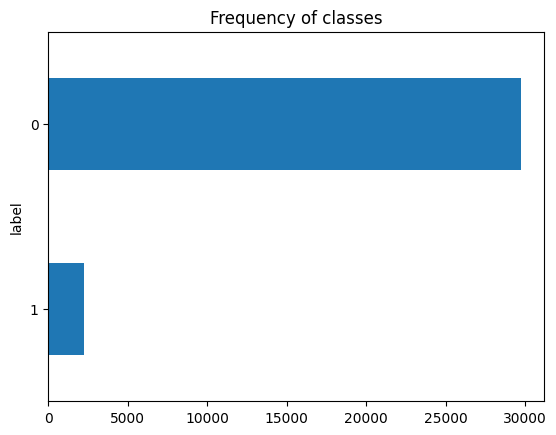

In [ ]:
# Observe the distribution of classes
df["label"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of classes")
plt.show()

This is clearly an unbalanced dataset

##Shrinking the dataset

In [ ]:
# Get the count of each class
class_counts = df['label'].value_counts()

# Determine the maximum number of samples I can take from the smallest class
max_samples_from_smallest_class = class_counts.min()

# I wanted a balanced dataset but capped at 10,000 rows
# First, I checked if doubling the smallest class count exceeds 10,000
if max_samples_from_smallest_class * len(class_counts) > 10000:
    # If yes, then I limited by the 10,000 rows target
    samples_per_class = 10000 // len(class_counts)
else:
    # If no, then i use the max_samples_from_smallest_class for balance
    samples_per_class = max_samples_from_smallest_class

balanced_samples = []
for label in class_counts.index:
    num_samples = min(samples_per_class, class_counts[label])
    sampled_df = df[df['label'] == label].sample(n=num_samples, random_state=42)
    balanced_samples.append(sampled_df)

# Concatenated the sampled subsets into one DataFrame
balanced_df = pd.concat(balanced_samples).sample(frac=1, random_state=42).reset_index(drop=True)
print(balanced_df['label'].value_counts())

# Converted the balanced DataFrame back to a Hugging Face dataset for training
dataset = Dataset.from_pandas(balanced_df)
print(dataset)

label
0    2242
1    2242
Name: count, dtype: int64
Dataset({
    features: ['label', 'tweet'],
    num_rows: 4484
})


In [ ]:
# Here I shuffled dataset
shuffled = dataset.shuffle(seed=42)
# Calculated split sizes
total_size = len(shuffled)
train_size = int(0.8 * total_size)
test_size = total_size - train_size  # This would be the remaining data for testing

# Final Spliting
train_dataset = shuffled.select(range(train_size))
test_dataset = shuffled.select(range(train_size, total_size))

dataset_dict = DatasetDict({
    'train': train_dataset,
    'test': test_dataset
})

# Accessing the splits
train_data = dataset_dict['train']
test_data = dataset_dict['test']
print(f"Training samples: {len(train_data)}")
print(f"Testing samples: {len(test_data)}")
print(dataset_dict)

Training samples: 3587
Testing samples: 897
DatasetDict({
    train: Dataset({
        features: ['label', 'tweet'],
        num_rows: 3587
    })
    test: Dataset({
        features: ['label', 'tweet'],
        num_rows: 897
    })
})


#MODEL 1: BERT

It's a type of deep learning model that excels at deciphering textual meaning in great detail. BERT can examine a sentence's relationship between words by considering the words that come before and after each other. As a result, BERT is able to understand textual context more precisely than older models. BERT is great in tasks regarding text classification,due to its context-awareness.



## BERT:Tokenization
I'm initializing a BERT tokenizer using the "bert-base-uncased" configuration.

I defined a function called tokenize(batch) that takes a batch of data from the dataset and tokenizes the "tweet" column using the tokenizer I initialized earlier. I specifyied padding and truncation parameters to ensure that all sequences have the same length, which was necessary for efficient processing by the model.



In [ ]:
device = torch.device( "cpu")

model1 = BertModel.from_pretrained('bert-base-uncased')
model1.to(device)
device

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

device(type='cpu')

In [ ]:
# Tokenize the full dataset
# I will use the map() method of the DatasertDict object
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
def tokenize(batch):
  return tokenizer(batch["tweet"], padding = True, truncation = True)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
dataset_dict1 = dataset_dict.map(tokenize, batched = True, batch_size = None)

Map:   0%|          | 0/3587 [00:00<?, ? examples/s]

Map:   0%|          | 0/897 [00:00<?, ? examples/s]

In [ ]:
#After tokenization, I print out the column names of the newly tokenized dataset (dataset_encoded) to verify that the tokenization process was successful.
print(dataset_dict1.column_names)

{'train': ['label', 'tweet', 'input_ids', 'token_type_ids', 'attention_mask'], 'test': ['label', 'tweet', 'input_ids', 'token_type_ids', 'attention_mask']}


In [ ]:
print(dataset_dict1) #To see an example of how the data looks after tokenization.

DatasetDict({
    train: Dataset({
        features: ['label', 'tweet', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3587
    })
    test: Dataset({
        features: ['label', 'tweet', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 897
    })
})


##BERT:Training the Classifier

First, we need to define a function that takes a batch of input data and returns the last hidden states of the BERT model:

In this example, we load the pretrained BERT model using the BertModel.from_pretrained() method, and then use the model to compute the last hidden states of the input data. We wrap the model call in a torch.no_grad() context to disable gradient computation, since we are only interested in extracting features and not training the model.

##BERT:Feature extraction (LOGISTIC REGRRESSION)

I have implemented a feature-based transfer learning approach using BERT as a feature extractor and a logistic regression model as the classifier. This is an effective method for leveraging the power of pre-trained language models for our classification tasks.

Feature Extraction + Logistic Regression: I used a pre-trained model to extract features, then train a separate model ( Logistic Regression) to classify those features. The pre-trained model does not change; only the Logistic Regression weights are updated.



###Extracting Hidden States:

In [ ]:
# I defined a function called extract_hidden_states(batch) to extract the last hidden states from the BERT model.
def extract_hidden_states(batch):
  # I Prepare the model inputs and move them on the GPU
  inputs = {k:v.to(device) for k,v in batch.items()
            if k in tokenizer.model_input_names}
  # Extract last hidden states usign the BERT model
  with torch.no_grad():
    last_hidden_state = model1(**inputs).last_hidden_state
  # Return the final hidden states back on the CPU as a NumPy array
  return{"hidden_state": last_hidden_state[:,0].cpu().numpy()}

###Preparing Data:

In [ ]:
# I expect tensors as inputs, so I converted to torch format
dataset_dict1.set_format("torch", columns = ["input_ids", "attention_mask", "label"])

In [ ]:
# Then I use the map() function to extract the hidden states from the dataset with a smaller batch size and save them to disk
dataset_hidden = dataset_dict1.map(extract_hidden_states, batched=True, batch_size=8)

Map:   0%|          | 0/3587 [00:00<?, ? examples/s]

Map:   0%|          | 0/897 [00:00<?, ? examples/s]

In [ ]:
dataset_hidden.save_to_disk("hidden_states.arrow") # To save time if I have to run the code again as extraction takes very long.
dataset_hidden = DatasetDict.load_from_disk("hidden_states.arrow")

Saving the dataset (0/1 shards):   0%|          | 0/3587 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/897 [00:00<?, ? examples/s]

In [ ]:
# We now prepare the data in a feature matrix and target vectors
X_train = np.array(dataset_hidden["train"]["hidden_state"])
X_test = np.array(dataset_hidden["test"]["hidden_state"])
y_train = np.array(dataset_hidden["train"]["label"])
y_test = np.array(dataset_hidden["test"]["label"])
X_train.shape, X_test.shape

((3587, 768), (897, 768))

###Training the Logistic Regression Classifier:

In [ ]:
X_train

array([[ 0.17328909,  0.41701093, -0.2003643 , ..., -0.30950472,
         0.25502428,  0.40670866],
       [-0.17210928,  0.12073734,  0.02320858, ...,  0.02904312,
         0.7241416 ,  0.5493285 ],
       [ 0.13107836,  0.00903966,  0.2664602 , ..., -0.43844092,
         0.35164064,  0.0475947 ],
       ...,
       [ 0.25159755, -0.10657635,  0.0732471 , ..., -0.16070363,
         0.06654796,  0.4235303 ],
       [-0.28240207,  0.21802516, -0.11652505, ..., -0.39080256,
         0.07115529,  0.5059969 ],
       [-0.02673423,  0.2534434 , -0.03303367, ..., -0.42453197,
         0.02512472,  0.28138855]], dtype=float32)

In [ ]:
# We increase "max_iter" to guarantee convergence
lr_clf1 = LogisticRegression(max_iter = 3600, verbose = 1)
lr_clf1.fit(X_train, y_train)
lr_clf1.score(X_test, y_test)

0.8729096989966555

###Evaluation:

In [ ]:
y_preds_lr1 = lr_clf1.predict(X_test)## MIGHT NOT NEED THIS
accuracy_lr1 = accuracy_score(y_test, y_preds_lr1)
print(f"Logistic Regression Accuracy: {accuracy_lr1}")

Logistic Regression Accuracy: 0.8729096989966555


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, log_loss

# Predictions
predictions = lr_clf1.predict(X_test)
probabilities = lr_clf1.predict_proba(X_test)  # For ROC-AUC and Log Loss

# Accuracy
accuracy = accuracy_score(y_test, predictions)

# Precision
precision = precision_score(y_test, predictions)

# Recall
recall = recall_score(y_test, predictions)

# F1 Score
f1 = f1_score(y_test, predictions)

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, probabilities[:, 1])

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)

# Log Loss
loss = log_loss(y_test, probabilities)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"ROC-AUC Score: {roc_auc}")
print(f"Confusion Matrix:\n{cm}")
print(f"Log Loss: {loss}")


Accuracy: 0.8729096989966555
Precision: 0.87248322147651
Recall: 0.87248322147651
F1 Score: 0.87248322147651
ROC-AUC Score: 0.9335520755654982
Confusion Matrix:
[[393  57]
 [ 57 390]]
Log Loss: 0.3376749117536293


Confusion matrix

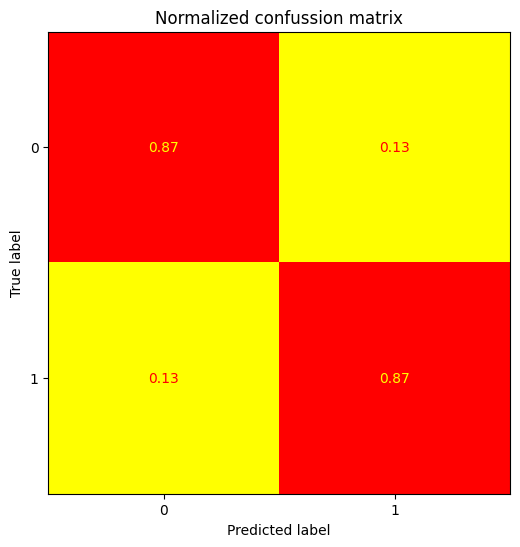

In [ ]:
# We can inspect the confussion matrix of the classifier
def plot_confusion_matrix(y_preds, y_true):
  cm = confusion_matrix(y_true, y_preds, normalize = "true")
  fig, ax = plt.subplots(figsize=(6, 6))
  disp = ConfusionMatrixDisplay(confusion_matrix = cm)
  disp.plot(cmap="autumn_r", values_format = ".2f", ax=ax, colorbar=False)
  plt.title("Normalized confussion matrix")
  plt.show()

y_preds = lr_clf1.predict(X_test)
plot_confusion_matrix(y_preds, y_test)

##BERT: Hyperparameter Tuning
I wanted to experiment with different settings for the model's hyperparameters to find the combination that gets me the best performance.

###Initializing BERT Model:

In [ ]:
model1 = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)  # Use num_labels = 2 because hate and Non-hate
model1.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

###Defining Performance Metrics:

In [ ]:
# Define the performance metrics
# We need to define a compute_metrics() function for the Trainer
def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels, preds, average = "weighted")
  acc = accuracy_score(labels, preds)
  return {"accuracy": acc, "f1": f1}

###Hyperparameter Tuning with Optuna:
I set up a hyperparameter tuning process using Optuna, which will search for the optimal combination of hyperparameters to minimize the evaluation loss.

In [ ]:
def model_init():
    return model1

def objective(trial):
    # Hyperparameters to be tuned
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
    num_train_epochs = trial.suggest_int("num_train_epochs", 1,3)
    per_device_train_batch_size = trial.suggest_categorical("per_device_train_batch_size", [8, 16, 32])

    # Define training arguments
    training_args = TrainingArguments(
      output_dir="./results",
      evaluation_strategy="epoch",  # Evaluate at the end of each epoch
      save_strategy="epoch",  # Save at the end of each epoch to align with evaluation
      learning_rate=learning_rate,
      per_device_train_batch_size=per_device_train_batch_size,
      num_train_epochs=num_train_epochs,
      weight_decay=0.01,
      load_best_model_at_end=True,
      metric_for_best_model="eval_loss",)  # Specify the metric to determine the "best" model

    # Initialize the Trainer
    trainer = Trainer(
        model_init=model_init,
        args=training_args,
        train_dataset=dataset_dict["train"],
        eval_dataset=dataset_dict["test"],
        compute_metrics=compute_metrics,
    )

    # Train and evaluate
    trainer.train()
    eval_result = trainer.evaluate()

    # Objective: minimize evaluation loss
    return eval_result["eval_loss"]


In [ ]:
#Print out the best trial's hyperparameters to see the optimal configuration for the BERT model.
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=5)
print("Best trial:")
trial_ = study.best_trial
print(f"  Learning rate: {trial_.params['learning_rate']}")
print(f"  Num epochs: {trial_.params['num_train_epochs']}")
print(f"  Batch size: {trial_.params['per_device_train_batch_size']}")


[I 2024-04-07 18:00:43,567] A new study created in memory with name: no-name-a1889b05-ada5-42d0-b7b0-c63e9d92a8ba


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.247632,0.900780,0.900751
2,No log,0.255350,0.905240,0.905235


[I 2024-04-07 19:51:20,423] Trial 0 finished with value: 0.24763160943984985 and parameters: {'learning_rate': 4.149727586218774e-05, 'num_train_epochs': 2, 'per_device_train_batch_size': 32}. Best is trial 0 with value: 0.24763160943984985.
/usr/local/lib/python3.10/dist-packages/accelerate/accelerator.py:436: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.319112,0.905240,0.905233
2,No log,0.334730,0.905240,0.905236


[I 2024-04-07 21:42:13,979] Trial 1 finished with value: 0.31911221146583557 and parameters: {'learning_rate': 1.3137919271815141e-05, 'num_train_epochs': 2, 'per_device_train_batch_size': 16}. Best is trial 0 with value: 0.24763160943984985.
/usr/local/lib/python3.10/dist-packages/accelerate/accelerator.py:436: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.390026,0.884058,0.883690


[W 2024-04-07 22:52:59,663] Trial 2 failed with parameters: {'learning_rate': 4.977806758453145e-05, 'num_train_epochs': 2, 'per_device_train_batch_size': 8} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/optuna/study/_optimize.py", line 196, in _run_trial
    value_or_values = func(trial)
  File "<ipython-input-49-35579f160719>", line 35, in objective
    trainer.train()
  File "/usr/local/lib/python3.10/dist-packages/transformers/trainer.py", line 1780, in train
    return inner_training_loop(
  File "/usr/local/lib/python3.10/dist-packages/transformers/trainer.py", line 2118, in _inner_training_loop
    tr_loss_step = self.training_step(model, inputs)
  File "/usr/local/lib/python3.10/dist-packages/transformers/trainer.py", line 3045, in training_step
    self.accelerator.backward(loss)
  File "/usr/local/lib/python3.10/dist-packages/accelerate/accelerator.py", line 2013, in backward
    loss.ba

KeyboardInterrupt: 

The best parameters to minimize evaluation loss, which I found out from doing hyperparameter tuning were:

**learning_rate:** 4.149727586218774e-05

**num_train_epochs:** 2

**per_device_train_batch_size:** 32

##BERT: Finetunning
I then applied the set of parmeters we founf above in the fine tuning model of BERT.

In [ ]:
# TrainingArguments and Trainer for fine-tuning

batch_size = 32
logging_steps = len(dataset_hidden["train"]) # batch size
model_name = f"my-finetuned-hatespeech-dector"
training_args = TrainingArguments(output_dir = model_name,
                                      num_train_epochs = 2,
                                      learning_rate = 4.149727586218774e-05,
                                      per_device_train_batch_size = batch_size,
                                      per_device_eval_batch_size = batch_size,
                                      weight_decay = 0.01,
                                      evaluation_strategy = "epoch",
                                      disable_tqdm = False,
                                      logging_steps = logging_steps,
                                      push_to_hub = False,
                                      log_level = "error")

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
trainer = Trainer(model=model1, args = training_args,
                  compute_metrics = compute_metrics,
                  train_dataset = dataset_dict1["train"],
                  eval_dataset = dataset_dict1["test"],
                  tokenizer = tokenizer)

/usr/local/lib/python3.10/dist-packages/accelerate/accelerator.py:436: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.343370,0.888517,0.888420
2,No log,0.404860,0.899666,0.899646


TrainOutput(global_step=226, training_loss=0.1056608689569794, metrics={'train_runtime': 102.546, 'train_samples_per_second': 69.959, 'train_steps_per_second': 2.204, 'total_flos': 305990962940760.0, 'train_loss': 0.1056608689569794, 'epoch': 2.0})

In [ ]:
# We now can calculate the confussion matrix by taking the predictions from the validation set, first
preds_output = trainer.predict(dataset_dict["test"])

###Evaluation:

In [ ]:
preds_output.metrics

{'test_loss': 0.2644386291503906,
 'test_accuracy': 0.903010033444816,
 'test_f1': 0.903010033444816,
 'test_runtime': 8.4099,
 'test_samples_per_second': 106.66,
 'test_steps_per_second': 3.448}

##GRADIO DEMO FOR MODEL 1

In [ ]:
!pip install gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 34.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 14.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.6/313.6 kB 22.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 13.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.8/144.8 kB 20.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 40.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 9.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.9/129.9 kB 15.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 12.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 11.1 MB/s eta 0:00:00
  Created wheel for ffmpy: filename=ffmpy-0.3.2-py3-none-any.whl s

In [ ]:
import gradio as gr

In [ ]:
# Assuming your model and tokenizer are already loaded and named as `model1` and `tokenizer`
# Ensure model1 is on the correct device (CPU or CUDA)
model1.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

def predict_hate_speech(text):
    # Encode the input text
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)

    # Move tensors to the correct device
    inputs = {key: value.to(torch.device("cuda" if torch.cuda.is_available() else "cpu")) for key, value in inputs.items()}

    # Get predictions from model1
    with torch.no_grad():
        outputs = model1(**inputs)

    # Convert outputs (logits) to probabilities
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)

    # Extract probabilities
    probs = probabilities[0].tolist()

    # Assuming class 0 is 'Not Hate Speech' and class 1 is 'Hate Speech'
    return {"Not Hate Speech": probs[0], "Hate Speech": probs[1]}

# Create Gradio Interface
iface = gr.Interface(fn=predict_hate_speech,
                     inputs=gr.Textbox(lines=2, placeholder="Enter Text Here..."),
                     outputs=gr.Label(num_top_classes=2),
                     title="Hate Speech Detector",
                     description="Enter text to predict if it is hate speech or not.")

# Launch the interface
iface.launch()


Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://cb887cf1e9a98d5fc5.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


#XLNET MODEL
XLNet is an advanced model that does a really good job at understanding text. I wanted to challenge BERT and see if it will perform better or not. One reason for this is because XLNet uses something called permutation-based training. This helps XLNet understand words in different positions within a sentence.


###XLNET: Tokenization

In [ ]:
device2 = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
tokenizer2 = XLNetTokenizer.from_pretrained('xlnet-base-cased')
model2 = XLNetForSequenceClassification.from_pretrained('xlnet-base-cased', num_labels=2)  # Assuming binary classification
model2.to(device2)

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['logits_proj.bias', 'logits_proj.weight', 'sequence_summary.summary.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


XLNetForSequenceClassification(
  (transformer): XLNetModel(
    (word_embedding): Embedding(32000, 768)
    (layer): ModuleList(
      (0-11): 12 x XLNetLayer(
        (rel_attn): XLNetRelativeAttention(
          (layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ff): XLNetFeedForward(
          (layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (layer_1): Linear(in_features=768, out_features=3072, bias=True)
          (layer_2): Linear(in_features=3072, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (activation_function): GELUActivation()
        )
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (sequence_summary): SequenceSummary(
    (summary): Linear(in_features=768, out_features=768, bias=True)
    (activation): Tanh()
    (first_dropout): Identity()
    (last

In [ ]:
def tokenize_function(examples):
    return tokenizer2(examples["tweet"], padding="max_length", truncation=True, max_length=512)

dataset_dict2 = dataset_dict.map(tokenize_function, batched=True)


Map:   0%|          | 0/3587 [00:00<?, ? examples/s]

Map:   0%|          | 0/897 [00:00<?, ? examples/s]

## XLNET: FEATURE EXTRACTION WITH(LOGISTIC REGRESSION)

###Extracting Hidden States:

In [ ]:

device2 = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Moving model to the chosen device
model2 = XLNetModel.from_pretrained('xlnet-base-cased')
model2.to(device2)
model2.eval()

# Extracting the last hidden states
def extract_hidden_states(batch):
  # Place model inputs on the GPU
  inputs = {k:v.to(device2) for k,v in batch.items()
            if k in tokenizer2.model_input_names}
  # Extract last hidden states
  with torch.no_grad():
    last_hidden_state = model2(**inputs).last_hidden_state
  # Return the final hidden stated back on the CPU as a NumPy array
  return{"hidden_state": last_hidden_state[:,0].cpu().numpy()}

# We expects tensors as inputs, so we need to convert to torch format
dataset_dict2.set_format("torch", columns = ["input_ids", "attention_mask", "label"])

# Applying feature extraction
dataset_dict2 = {split: ds.map(extract_hidden_states, batched=True, batch_size=16) for split, ds in dataset_dict2.items()}


Map:   0%|          | 0/3587 [00:00<?, ? examples/s]

KeyboardInterrupt: 

###Preparing Data and Feature Extraction:

In [ ]:
X_train = np.array(dataset_dict2["train"]["hidden_state"])
X_test = np.array(dataset_dict2["test"]["hidden_state"])
y_train = np.array(dataset_dict2["train"]["label"])
y_test = np.array(dataset_dict2["test"]["label"])
X_train.shape, X_test.shape


((3587, 768), (897, 768))

In [ ]:
X_train

array([[-1.067296  ,  6.4645357 , -3.6314652 , ..., -2.0760581 ,
        -1.2836198 , -2.6858284 ],
       [-3.847849  ,  4.7380548 ,  0.9305861 , ..., -0.3584489 ,
         1.7319123 , -0.19840965],
       [-1.0142525 ,  2.817355  , -2.5437582 , ...,  1.2306714 ,
         1.1843193 , -1.5694652 ],
       ...,
       [-2.1838386 ,  2.3181162 , -0.01344818, ..., -0.6727354 ,
         1.2941425 , -2.3186045 ],
       [-0.3217578 ,  2.901717  , -3.1028767 , ...,  0.8046621 ,
         0.85343903, -1.1958671 ],
       [-1.6098555 ,  1.5974036 , -3.4476538 , ..., -0.83936167,
         0.15300362, -0.9190404 ]], dtype=float32)

###Training Logistic Regression Classifier:

In [ ]:
lr_clf2 = LogisticRegression(max_iter = 3600, verbose = 1)
lr_clf2.fit(X_train, y_train)
lr_clf2.score(X_test, y_test)

0.7402452619843924

###Evaluation:
Performance metrics including accuracy, precision, recall, F1-score, ROC-AUC score, confusion matrix, and log loss are printed out to evaluate the classifier's effectiveness in identifying hate speech.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, log_loss

# Predictions
predictions = lr_clf2.predict(X_test)
probabilities = lr_clf2.predict_proba(X_test)  # For ROC-AUC and Log Loss

# Accuracy
accuracy = accuracy_score(y_test, predictions)

# Precision
precision = precision_score(y_test, predictions)

# Recall
recall = recall_score(y_test, predictions)

# F1 Score
f1 = f1_score(y_test, predictions)

# ROC-AUC Score
# Note: roc_auc_score requires probability scores of the positive class, probabilities[:, 1] in this case
roc_auc = roc_auc_score(y_test, probabilities[:, 1])

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)

# Log Loss
loss = log_loss(y_test, probabilities)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"ROC-AUC Score: {roc_auc}")
print(f"Confusion Matrix:\n{cm}")
print(f"Log Loss: {loss}")


Accuracy: 0.7402452619843924
Precision: 0.7367256637168141
Recall: 0.7449664429530202
F1 Score: 0.7408231368186875
ROC-AUC Score: 0.8053840417598808
Confusion Matrix:
[[331 119]
 [114 333]]
Log Loss: 0.7814263578040874


## XLNET: FINETUNING  

In [ ]:
batch_size = 8
logging_steps = len(dataset_dict2["train"]) # batch size
model_name = f"my-finetuned-hatespeech-dector-2"
training_args = TrainingArguments(output_dir = model_name,
                                      num_train_epochs = 2,
                                      learning_rate = 2e-5,
                                      per_device_train_batch_size = batch_size,
                                      per_device_eval_batch_size = batch_size,
                                      weight_decay = 0.01,
                                      evaluation_strategy = "epoch",
                                      disable_tqdm = False,
                                      logging_steps = 100,
                                      push_to_hub = False,
                                      log_level = "error")

In [ ]:
# define a compute_metrics() function for the Trainer
def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels, preds, average = "weighted")
  acc = accuracy_score(labels, preds)
  return {"accuracy": acc, "f1": f1}



trainer2 = Trainer(model=model2, args = training_args,
                  compute_metrics = compute_metrics,
                  train_dataset = dataset_dict2["train"],
                  eval_dataset = dataset_dict2["test"],
                  tokenizer = tokenizer2)


/usr/local/lib/python3.10/dist-packages/accelerate/accelerator.py:436: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(


In [ ]:
trainer2.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.394200,0.317219,0.891862,0.891860
2,0.274900,0.370618,0.895206,0.895192


TrainOutput(global_step=898, training_loss=0.3673165476401824, metrics={'train_runtime': 1662.886, 'train_samples_per_second': 4.314, 'train_steps_per_second': 0.54, 'total_flos': 2043731125506048.0, 'train_loss': 0.3673165476401824, 'epoch': 2.0})

###Evaluation:

In [ ]:
trainer2.evaluate()

{'eval_loss': 0.3706181049346924,
 'eval_accuracy': 0.89520624303233,
 'eval_f1': 0.895192175497387,
 'eval_runtime': 116.6168,
 'eval_samples_per_second': 7.692,
 'eval_steps_per_second': 0.969,
 'epoch': 2.0}

In [ ]:
import gradio as gr
from transformers import BertTokenizer, BertForSequenceClassification
import torch

# Assuming your model and tokenizer are already loaded and named as `model1` and `tokenizer`
# Ensure model1 is on the correct device (CPU or CUDA)
model2.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

def predict_hate_speech(text):
    # Encode the input text
    inputs = tokenizer2(text, return_tensors="pt", padding=True, truncation=True, max_length=512)

    # Move tensors to the correct device
    inputs = {key: value.to(torch.device("cuda" if torch.cuda.is_available() else "cpu")) for key, value in inputs.items()}

    # Get predictions from model1
    with torch.no_grad():
        outputs = model2(**inputs)

    # Convert outputs (logits) to probabilities
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)

    # Extract probabilities
    probs = probabilities[0].tolist()

    # Assuming class 0 is 'Not Hate Speech' and class 1 is 'Hate Speech'
    return {"Not Hate Speech": probs[0], "Hate Speech": probs[1]}

# Create Gradio Interface
iface = gr.Interface(fn=predict_hate_speech,
                     inputs=gr.Textbox(lines=2, placeholder="Enter Text Here..."),
                     outputs=gr.Label(num_top_classes=2),
                     title="Hate Speech Detector",
                     description="Enter text to predict if it is hate speech or not.")

# Launch the interface
iface.launch()


Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://0397ffff17927bd977.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


#DISTILBERT
DistilBERT is like a "lighter" version of BERT, designed to be faster and use fewer computational resources. Despite being smaller, it still works pretty well and maintains much of BERT's accuracy. It's great for tasks where speed and efficiency matter just as much as getting the right answers. Since the is limitation to how long it takes to process data or how much computing power i have ,i thought about giving DistilBERT a shot.

##DiltilBERT: Tokenization

In [ ]:
tokenizer3 = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model3 = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)  # For binary classification of hate and non hate


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def tokenize_function(examples):
    return tokenizer3(examples["tweet"], padding="max_length", truncation=True, max_length=512,return_tensors="pt")

dataset_dict3 = dataset_dict.map(tokenize_function, batched=True)


Map:   0%|          | 0/3587 [00:00<?, ? examples/s]

Map:   0%|          | 0/897 [00:00<?, ? examples/s]

##DiltilBERT: Feature Extraction with Logistic Regression

###Extracting Hidden States:

In [ ]:
# Updating the device setup to use GPU if available
device3 = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Loading the DistilBERT model
model3 = DistilBertModel.from_pretrained('distilbert-base-uncased')
model3.to(device3)
model3.eval()

# Extracting the last hidden states
def extract_hidden_states(batch):
  # Place model inputs on the GPU
  inputs = {k:v.to(device3) for k,v in batch.items()
            if k in tokenizer3.model_input_names}
  # Extract last hidden states
  with torch.no_grad():
    last_hidden_state = model3(**inputs).last_hidden_state
  # Return the final hidden stated back on the CPU as a NumPy array
  return{"hidden_state": last_hidden_state[:,0].cpu().numpy()}

# Expecting tensors as inputs, so we need to convert to torch format
dataset_dict3.set_format("torch", columns = ["input_ids", "attention_mask", "label"])

# Applying feature extraction
dataset_dict3 = {split: ds.map(extract_hidden_states, batched=True, batch_size=16) for split, ds in dataset_dict3.items()}


Map:   0%|          | 0/3587 [00:00<?, ? examples/s]

Map:   0%|          | 0/897 [00:00<?, ? examples/s]

###Preparing Data and Feature Extraction:

In [ ]:
# Preparing the data in a feature matrix
X_train = np.array(dataset_dict3["train"]["hidden_state"])
X_test = np.array(dataset_dict3["test"]["hidden_state"])
y_train = np.array(dataset_dict3["train"]["label"])
y_test = np.array(dataset_dict3["test"]["label"])
X_train.shape, X_test.shape


((3587, 768), (897, 768))

In [ ]:
X_train

array([[ 0.2549221 ,  0.04261632, -0.13590279, ..., -0.26981238,
         0.38345453,  0.25423357],
       [-0.16993248, -0.01665899,  0.05153944, ..., -0.02974233,
         0.49058685,  0.28374314],
       [ 0.14630361, -0.1378148 ,  0.01624794, ..., -0.04763622,
         0.25021538,  0.48937553],
       ...,
       [ 0.0821537 , -0.10415168, -0.03704366, ..., -0.07319593,
         0.21061762,  0.5639491 ],
       [-0.19017097, -0.17093833,  0.09173135, ..., -0.04656041,
         0.07485358,  0.33401203],
       [ 0.13328505, -0.1511633 , -0.12180194, ..., -0.02481473,
        -0.00718979,  0.4408002 ]], dtype=float32)

###Training Logistic Regression Classifier:

In [ ]:
# We now train a LogisticRegression Classiffier
# We increase "max_iter" to guarantee convergence
lr_clf3 = LogisticRegression(max_iter = 3600, verbose = 1)
lr_clf3.fit(X_train, y_train)
lr_clf3.score(X_test, y_test)

0.8706800445930881

###Evaluation:

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, log_loss

# Predictions
predictions = lr_clf3.predict(X_test)
probabilities = lr_clf3.predict_proba(X_test)  # For ROC-AUC and Log Loss

# Accuracy
accuracy = accuracy_score(y_test, predictions)

# Precision
precision = precision_score(y_test, predictions)

# Recall
recall = recall_score(y_test, predictions)

# F1 Score
f1 = f1_score(y_test, predictions)

# ROC-AUC Score
# Note: roc_auc_score requires probability scores of the positive class, probabilities[:, 1] in this case
roc_auc = roc_auc_score(y_test, probabilities[:, 1])

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)

# Log Loss
loss = log_loss(y_test, probabilities)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"ROC-AUC Score: {roc_auc}")
print(f"Confusion Matrix:\n{cm}")
print(f"Log Loss: {loss}")


Accuracy: 0.8706800445930881
Precision: 0.8719101123595505
Recall: 0.8680089485458613
F1 Score: 0.8699551569506726
ROC-AUC Score: 0.9443052448421576
Confusion Matrix:
[[393  57]
 [ 59 388]]
Log Loss: 0.29998837105365533


##DistilBERT Model: HYPERPARAMETER TUNING

###Initializing DistilBERT Model:

In [ ]:
# Initialize the model for sequence classification
model3 = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


###Defining Performance Metrics:

In [ ]:
def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels, preds, average = "weighted")
  acc = accuracy_score(labels, preds)
  return {"accuracy": acc, "f1": f1}

###Hyperparameter Tuning with Optuna:

In [ ]:
from transformers import DistilBertForSequenceClassification, TrainingArguments, Trainer
import optuna

def model_init():
    return model3

def objective(trial):
    training_args = TrainingArguments(
        output_dir='./results',
        evaluation_strategy="epoch",
        learning_rate=trial.suggest_loguniform('learning_rate', 1e-5, 5e-4),
        per_device_train_batch_size=trial.suggest_categorical('batch_size', [4, 8]),  # Smaller batch sizes to conserve GPU memory
        gradient_accumulation_steps=trial.suggest_int('accumulation_steps', 1, 4),
        num_train_epochs=trial.suggest_int('num_train_epochs', 1, 3),
        weight_decay=trial.suggest_float('weight_decay', 0, 0.1),
        logging_dir='./logs',
        report_to='none',
    )

    trainer3_ht = Trainer(
        model_init=model_init,
        args=training_args,
        train_dataset=dataset_dict3['train'],
        eval_dataset=dataset_dict3['test'],
        compute_metrics=compute_metrics,  # Define a function to compute metrics
    )

    trainer3_ht.train()
    eval_result = trainer3_ht.evaluate()

    return eval_result["eval_loss"]

# Start the hyperparameter optimization
study3 = optuna.create_study(direction="minimize")
study3.optimize(objective, n_trials=3)

print("Best trial:")
print(study3.best_trial.params)


[I 2024-04-09 12:42:01,265] A new study created in memory with name: no-name-13f5cd11-5732-4f62-82d5-8a257619aa24
<ipython-input-19-23a74813d967>:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate=trial.suggest_loguniform('learning_rate', 1e-5, 5e-4),
/usr/local/lib/python3.10/dist-packages/accelerate/accelerator.py:436: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.666800,0.699210,0.498328,0.331477
2,0.698000,0.575049,0.712375,0.696430


[I 2024-04-09 12:48:57,867] Trial 0 finished with value: 0.575048565864563 and parameters: {'learning_rate': 0.0002298937232697843, 'batch_size': 4, 'accumulation_steps': 1, 'num_train_epochs': 2, 'weight_decay': 0.09303411791174458}. Best is trial 0 with value: 0.575048565864563.
<ipython-input-19-23a74813d967>:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate=trial.suggest_loguniform('learning_rate', 1e-5, 5e-4),
/usr/local/lib/python3.10/dist-packages/accelerate/accelerator.py:436: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_ba

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.455067,0.807135,0.807098


[I 2024-04-09 12:52:10,093] Trial 1 finished with value: 0.4550667703151703 and parameters: {'learning_rate': 1.812498434668388e-05, 'batch_size': 8, 'accumulation_steps': 1, 'num_train_epochs': 1, 'weight_decay': 0.032160866409399816}. Best is trial 1 with value: 0.4550667703151703.
<ipython-input-19-23a74813d967>:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate=trial.suggest_loguniform('learning_rate', 1e-5, 5e-4),
/usr/local/lib/python3.10/dist-packages/accelerate/accelerator.py:436: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch

Epoch,Training Loss,Validation Loss,Accuracy,F1
0,No log,0.472367,0.819398,0.818729
1,No log,0.404227,0.839465,0.839439
2,No log,0.403812,0.843924,0.843367


[I 2024-04-09 13:00:58,819] Trial 2 finished with value: 0.40381237864494324 and parameters: {'learning_rate': 7.131340763125469e-05, 'batch_size': 8, 'accumulation_steps': 4, 'num_train_epochs': 3, 'weight_decay': 0.06988715961331936}. Best is trial 2 with value: 0.40381237864494324.


Best trial:
{'learning_rate': 7.131340763125469e-05, 'batch_size': 8, 'accumulation_steps': 4, 'num_train_epochs': 3, 'weight_decay': 0.06988715961331936}


In [ ]:
print("Best trial:")
print(study3.best_trial.params)

Best trial:
{'learning_rate': 2.937821963176617e-05, 'batch_size': 8, 'accumulation_steps': 4, 'num_train_epochs': 3, 'weight_decay': 0.06456387141831647}


The best parameters to minimize evaluation loss, which I found out from doing hyperparameter tuning multiple times for DistilBERT were:

**learning_rate:** 2.937821963176617e-05

**num_train_epochs:** 3

**accumulation_steps:** 4

**weight_decay:** 0.06456387141831647

**per_device_train_batch_size:** 8 (if higher it would be better)

##DiltilBERT: Finetunning

In [ ]:
batch_size = 8
logging_steps = len(dataset_dict["train"]) # batch size
model_name = f"my-finetuned-hatespeech-dector-3"
training_args = TrainingArguments(output_dir = model_name,
                                      num_train_epochs = 3,
                                      gradient_accumulation_steps= 4,
                                      learning_rate = 2.937821963176617e-05,
                                      per_device_train_batch_size = batch_size,
                                      per_device_eval_batch_size = batch_size,
                                      weight_decay = 0.06456387141831647,
                                      evaluation_strategy = "epoch",
                                      disable_tqdm = False,
                                      logging_steps = logging_steps,
                                      push_to_hub = False,
                                      log_level = "error")

In [ ]:
trainer3 = Trainer(model=model3, args = training_args,
                  compute_metrics = compute_metrics,
                  train_dataset = dataset_dict3["train"],
                  eval_dataset = dataset_dict3["test"],
                  tokenizer = tokenizer3)

/usr/local/lib/python3.10/dist-packages/accelerate/accelerator.py:436: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(


In [ ]:
trainer3.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1
0,No log,0.384742,0.851728,0.851329
1,No log,0.401335,0.858417,0.858128
2,No log,0.397733,0.857302,0.856901


TrainOutput(global_step=336, training_loss=0.27067161741710843, metrics={'train_runtime': 507.8427, 'train_samples_per_second': 21.19, 'train_steps_per_second': 0.662, 'total_flos': 1422964796362752.0, 'train_loss': 0.27067161741710843, 'epoch': 2.99})

###Evaluation

In [ ]:
trainer3.evaluate()

{'eval_loss': 0.49583497643470764,
 'eval_accuracy': 0.9096989966555183,
 'eval_f1': 0.9096969764310512,
 'eval_runtime': 31.1838,
 'eval_samples_per_second': 28.765,
 'eval_steps_per_second': 3.624,
 'epoch': 2.99}

#GRADIO OF BEST MODEL

In [ ]:
!pip install gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 44.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 11.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.6/313.6 kB 33.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.8/144.8 kB 17.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 91.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.9/129.9 kB 15.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 10.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 9.6 MB/s eta 0:00:00
  Created wheel for ffmpy: filename=ffmpy-0.3.2-py3-none-any.whl si

In [ ]:
import gradio as gr
from transformers import BertTokenizer, BertForSequenceClassification
import torch

# Assuming your model and tokenizer are already loaded and named as `model1` and `tokenizer`
# Ensure model1 is on the correct device (CPU or CUDA)
model3.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

def predict_hate_speech(text):
    # Encode the input text
    inputs = tokenizer3(text, return_tensors="pt", padding=True, truncation=True, max_length=512)

    # Move tensors to the correct device
    inputs = {key: value.to(torch.device("cuda" if torch.cuda.is_available() else "cpu")) for key, value in inputs.items()}

    # Get predictions from model1
    with torch.no_grad():
        outputs = model3(**inputs)

    # Convert outputs (logits) to probabilities
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)

    # Extract probabilities
    probs = probabilities[0].tolist()

    # Assuming class 0 is 'Not Hate Speech' and class 1 is 'Hate Speech'
    return {"Not Hate Speech": probs[0], "Hate Speech": probs[1]}

# Create Gradio Interface
iface = gr.Interface(fn=predict_hate_speech,
                     inputs=gr.Textbox(lines=2, placeholder="Enter Text Here..."),
                     outputs=gr.Label(num_top_classes=2),
                     title="Hate Speech Detector",
                     description="Enter text to predict if it is hate speech or not.")

# Launch the interface
iface.launch()


Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://1d03dec6101e3df751.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)
